In [ ]:
import numpy as np
import pandas as pd
import ast
#matplotlib 
import matplotlib.pyplot as plt
import os   

DATASET_ROOT = "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1"

ptbxl_path = "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\\ptbxl_database.csv"
scp_path = "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\\scp_statements.csv"

df = pd.read_csv(ptbxl_path)
scp_df = pd.read_csv(scp_path, index_col=0)
df.head()

df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)
df["scp_codes"].iloc[0]
scp_df = scp_df[scp_df["diagnostic"] == 1]

scp_to_superclass = scp_df["diagnostic_class"].to_dict()
def extract_superclasses(scp_dict):
    classes = set()
    for code in scp_dict.keys():
        if code in scp_to_superclass:
            classes.add(scp_to_superclass[code])
    return list(classes)

df["diagnostic_superclass"] = df["scp_codes"].apply(extract_superclasses)
df = df[df["diagnostic_superclass"].map(len) > 0]
df.shape


(21430, 29)

In [3]:
from collections import Counter

all_classes = []
for classes in df["diagnostic_superclass"]:
    all_classes.extend(classes)

class_counts = Counter(all_classes)
class_counts


Counter({'NORM': 9528, 'MI': 5486, 'STTC': 5250, 'CD': 4907, 'HYP': 2655})

In [4]:
top_4_classes = ["NORM", "MI", "STTC", "CD"]
def select_single_class(classes):
    filtered = [c for c in classes if c in top_4_classes]
    return filtered[0] if len(filtered) == 1 else None

df["target_class"] = df["diagnostic_superclass"].apply(select_single_class)
df = df[df["target_class"].notna()]


In [5]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["target_encoded"] = label_encoder.fit_transform(df["target_class"])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
label_mapping


{'CD': np.int64(0),
 'MI': np.int64(1),
 'NORM': np.int64(2),
 'STTC': np.int64(3)}

In [6]:
y = df["target_encoded"].values


from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    np.arange(len(df)),
    test_size=0.2,
    stratify=y,
    random_state=42
)
from collections import Counter

print("Train distribution:", Counter(y[train_idx]))
print("Test distribution:", Counter(y[test_idx]))



Train distribution: Counter({np.int64(2): 7268, np.int64(3): 2551, np.int64(1): 2177, np.int64(0): 1607})
Test distribution: Counter({np.int64(2): 1817, np.int64(3): 638, np.int64(1): 544, np.int64(0): 402})


In [7]:
import wfdb

def load_ecg(record_path):
    full_path = DATASET_ROOT + "/" + record_path
    signal, _ = wfdb.rdsamp(full_path, sampto=1000)
    return signal.T


N_SAMPLES = 21000  
df_small = df.iloc[:N_SAMPLES]

X = np.array([load_ecg(p) for p in df_small["filename_lr"]])
y_small = df_small["target_encoded"].values

X.shape





(17004, 12, 1000)

In [8]:
np.save("X_ecg.npy", X)
np.save("y_ecg.npy", y_small)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_small,
    test_size=0.2,
    stratify=y_small,
    random_state=42
)


In [10]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=32,
    shuffle=False
)


In [11]:
import torch.nn as nn
import torch.nn.functional as F



class ECGCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # ----- Block 1: Low-level waveform features -----
        self.conv1 = nn.Conv1d(
            in_channels=12,
            out_channels=32,
            kernel_size=7,
            padding=3
        )
        self.bn1 = nn.BatchNorm1d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        # ----- Block 2: Higher-level temporal features -----
        self.conv2 = nn.Conv1d(
            in_channels=32,
            out_channels=64,
            kernel_size=5,
            padding=2
        )
        self.bn2 = nn.BatchNorm1d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        # ----- Classification head -----
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 250, 128)  # 1000 → 500 → 250
        self.relu_fc = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Input shape: (batch, 12, 1000)

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        # Shape now: (batch, 32, 500)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        # Shape now: (batch, 64, 250)

        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu_fc(x)
        x = self.fc2(x)

        return x


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ECGCNN(num_classes=4).to(device)
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 10

for epoch in range(epochs):
    model.train()
    correct = total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    print(f"Epoch {epoch+1}: Train Accuracy = {correct / total:.4f}")


Epoch 1: Train Accuracy = 0.5935
Epoch 2: Train Accuracy = 0.7068
Epoch 3: Train Accuracy = 0.7306
Epoch 4: Train Accuracy = 0.7599
Epoch 5: Train Accuracy = 0.7825
Epoch 6: Train Accuracy = 0.8059
Epoch 7: Train Accuracy = 0.8239
Epoch 8: Train Accuracy = 0.8380
Epoch 9: Train Accuracy = 0.8667
Epoch 10: Train Accuracy = 0.8850


In [13]:
from sklearn.metrics import accuracy_score, f1_score

model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        outputs = model(xb)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

print("CNN Accuracy:", accuracy_score(all_true, all_preds))
print("CNN Macro F1:", f1_score(all_true, all_preds, average="macro"))


CNN Accuracy: 0.7283152014113496
CNN Macro F1: 0.6751427390711064


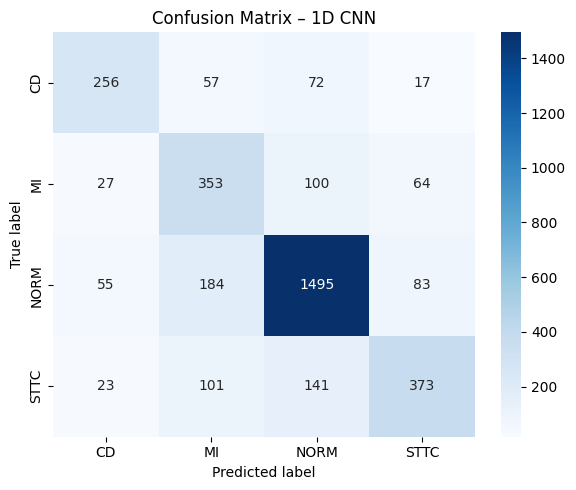

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix – 1D CNN")
plt.tight_layout()
plt.show()

In [15]:
torch.save(model.state_dict(), "ecg_cnn.pt")
import pickle

with open("label_classes.pkl", "wb") as f:
    pickle.dump(label_encoder.classes_, f)
